In [1]:
import h5py
import numpy as np
import os
import pandas as pd
import pathlib
import pickle
import scipy.stats as stats
import soxr
#! change below to spatial_attn_lighting if want to use with modular 
import src.spatial_attn_lightning as attn_tracking_lightning
import src.audio_transforms as at
import torch
import yaml

import argparse
from argparse import ArgumentParser
from corpus.speaker_room_dataset import SpeakerRoomDataset
from corpus.swc_mono_test import SWCMonoTestSet

from tqdm.auto import tqdm
from datetime import datetime
import sys 

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Spatialize(torch.nn.Module):
    def __init__(self, ir, model_sr=50_000):
        super(Spatialize, self).__init__()
        ir = torch.flip(torch.from_numpy(ir), dims=[0]).float()
        self.n_taps = ir.shape[0]
        ir = ir.T.unsqueeze(1)
        # set center crop of 2.5 seconds relative to model_sr
        self.start_frame = int(model_sr * 0.25)
        self.end_frame = int(model_sr * 2.75)

        self.register_buffer("ir", ir)

    def forward(self, words):
        n_words = words.shape[0]
        # pad last dim of words with ir.shape[0] - 1 zeros
        words_padded = torch.nn.functional.pad(words, (self.n_taps - 1, 0))
        spatialized = torch.nn.functional.conv1d(words_padded.view(n_words, 1, -1), self.ir)
        # resize to desired shape
        spatialized = spatialized[:, :, self.start_frame:self.end_frame]
        return spatialized

In [3]:
### Get most recent config
config_path = "config/binaural_attn/word_task_20p_loc_v07_wider_SNR_residual_attn.yaml"
ckpt_path = "attn_cue_models/word_task_20p_loc_v07_wider_SNR_residual_attn/checkpoints/epoch=3-step=42302-v1.ckpt"

In [4]:

config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
config['num_workers'] = 2
config['hparas']['batch_size'] = 60 # config['data']['loader']['batch_size'] // args.gpus
config['noise_kwargs']['low_snr'] = 0
config['noise_kwargs']['high_snr'] = 0
# get model input sr for brir resampling
model_in_sr = config['audio']['rep_kwargs']['sr']

In [5]:
model = attn_tracking_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=False).cuda()
model = model.eval()
coch_gram = model.coch_gram.cuda()

num_classes={'num_words': 800}
Model performing word task
Using residual attention


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [6]:
audio_transforms_0_db = at.AudioCompose([
                    at.AudioToTensor(),
                    at.BinauralCombineWithRandomDBSNR(low_snr=0,    # is 0 dB
                                                      high_snr=0), # is 0 dB 
                    at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02), # 20 * np.log10(0.02/20e-6) = 60 dB SPL 
            ])

audio_transforms_test_db = at.AudioCompose([
                    at.AudioToTensor(),
                    at.BinauralCombineWithRandomDBSNR(low_snr=3,    # is 0 dB
                                                      high_snr=3), # is 0 dB 
                    at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02), # 20 * np.log10(0.02/20e-6) = 60 dB SPL 
            ])

diotic_transforms = at.AudioCompose([
                    at.AudioToTensor(),
                    at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), 
                    at.RMSNormalizeForegroundAndBackground(rms_level=0.02),  # 0.02 is the default for CV-based models 
                    at.DuplicateChannel(),

            ])

audio_transforms_0_db = audio_transforms_0_db.cuda()
audio_transforms_test_db = audio_transforms_test_db.cuda()
diotic_transforms = diotic_transforms.cuda()



In [7]:
dataset = SpeakerRoomDataset(manifest_path='/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl',
                            excerpt_path='/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl',
                            cue_type='voice_and_location',
                            sr=model_in_sr) 

def single_signal_collate_fn(batch):
    #apply transforsms to batch
    cues = torch.stack([diotic_transforms(cue, None)[0] for cue, fg, bg, label, confusion in batch])
    mixtures = torch.stack([diotic_transforms(fg, None)[0] for cue, fg, bg, label, confusion in batch]).type(torch.FloatTensor)
    labels = torch.tensor([label for cue, fg, bg, label, confusion in batch]).type(torch.LongTensor)
    confusion = torch.tensor([confusion for cue, fg, bg, label, confusion in batch]).type(torch.LongTensor)
    return cues, mixtures, labels, confusion


dataloader = torch.utils.data.DataLoader(dataset, batch_size=48, shuffle=False, num_workers=config['num_workers'], collate_fn=single_signal_collate_fn)


In [8]:
# stim_path = "/om/user/imgriff/datasets/human_word_rec_SWC_2023/sounds/"
# dataset = SWCMonoTestSet(stim_path=stim_path,
#                             cond_ix=3, # 4 for music at 3 db, 40 for clean speech 
#                             model_sr=44100,
#                             label_type='CV')

# audio_transforms = at.AudioCompose([
#                     at.AudioToTensor(),
#                     # at.CombineWithRandomDBSNR(low_snr=snr, high_snr=snr), 
#                     at.RMSNormalizeForegroundAndBackground(rms_level=0.02),  # 0.02 is the default for CV-based models 
#                     at.UnsqueezeAudio(dim=0),
#                     at.DuplicateChannel()
#             ])  
# def collate_fn(batch):
#     #apply transforsms to batch
#     cues = torch.stack([audio_transforms(cue, None)[0] for cue, _, _ in batch])
#     mixtures = torch.stack([audio_transforms(mix, None)[0] for _, mix,  _ in batch])
#     labels = torch.tensor([label for _, _, label in batch]).type(torch.LongTensor)
#     return cues, mixtures, labels

# dataloader = torch.utils.data.DataLoader(dataset,
#                                              batch_size=16,
#                                              shuffle=False,
#                                              collate_fn=collate_fn,
#                                              num_workers=0)

In [9]:
# new_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_brir.pdpkl')
# only14_manifest = new_room_manifest[(new_room_manifest['src_dist'] == 1.4) & (new_room_manifest['index_room'] == 0)]

# ir_dict = dict()
# target_loc = (0, 0)
# distractor_loc = [0, 0]
# for loc in ['target', 'distractor_l', 'distractor_r']:
#     if loc == 'target':
#         coords = target_loc
#     elif loc == 'distractor_r':
#         coords = distractor_loc.copy()
#         coords[0] = 360 - coords[0] if coords[0] != 0 else 0 
#     elif loc == 'distractor_l':
#         coords = distractor_loc.copy()
#     # print(loc)
#     # print(coords)

#     df_row = only14_manifest[(only14_manifest['src_azim'] == coords[0]) & (only14_manifest['src_elev'] == coords[1])]
#     h5_fn = f'/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/room0000.hdf5'
#     index_brir = df_row['index_brir'].values[0]
#     sr_src = df_row['sr'].values[0]
#     with h5py.File(h5_fn, 'r') as f:
#         brir = f['brir'][index_brir]
#     if model_in_sr != sr_src:
#         brir = soxr.resample(brir.astype(np.float32), sr_src, model_in_sr)
#     ir_dict[loc] = brir.astype(np.float32)
# ir_dict

In [10]:
# tar_brir = Spatialize(ir_dict['target'], model_sr=model_in_sr).cuda()
# dist_brir_l = Spatialize(ir_dict['distractor_l'], model_sr=model_in_sr).cuda()
# dist_brir_r = Spatialize(ir_dict['distractor_r'], model_sr=model_in_sr).cuda()


### Try diotically first, then spatialize 

In [11]:
output_dict = {'results': None, 'confusions': None}
accuracies = []
pred_list = []
true_word_int = []
confusions_list  = []
all_probs_of_interest = []
guessed_both = []
ix = 0 
with torch.no_grad(): 
    for batch in tqdm(dataloader):
        # if ix > 10:
        #     break
        cue, mixture, label, confusion = batch
        # cue, fg, label = batch
        # just running diotically on fg 
        # cue, _ = audio_transforms(cue.cuda(), None)
        # mixture, _ = diotic_transforms(fg.cuda().squeeze(), None)
        # cue = cue.cuda()
        # mixture = mixture.cuda()
        cue, mixture = coch_gram(cue.cuda(), mixture.cuda())
        # cue_mask_ixs = torch.arange(cue.shape[0])
        logits = model(None, mixture, None)
        probs = logits.softmax(dim=-1).cpu().detach().numpy()

        # get top 2 probs for each example
        top_2_probs = torch.topk(logits.softmax(-1), 5, dim=-1).indices.cpu().detach().numpy()
        return_both = (np.isin(label.numpy(), top_2_probs) * np.isin(confusion.numpy(), top_2_probs)).astype('int')
        
        targ_probs = probs[torch.arange(probs.shape[0]), label]
        conf_probs = probs[torch.arange(probs.shape[0]), confusion]
        probs_of_interest = np.concatenate([targ_probs[:, None], conf_probs[:, None]], axis=1)

        preds = logits.softmax(dim=-1).argmax(dim=-1).cpu().detach().numpy().astype('int')
        true_word = label.numpy().astype('int')
        accuracy = (preds == true_word).astype('int')
        conf = (preds == confusion.numpy().astype('int')).astype('int')
        confusions_list.append(conf)
        accuracies.append(accuracy)
        pred_list.append(preds)
        true_word_int.append(true_word)
        all_probs_of_interest.append(probs_of_interest)
        guessed_both.append(return_both)
        ix += 1 
        
accuracies = np.concatenate(accuracies)
pred_list = np.concatenate(pred_list)
true_word_int = np.concatenate(true_word_int)
confusions_list = np.concatenate(confusions_list)
all_probs_of_interest = np.concatenate(all_probs_of_interest, axis=0)
guessed_both = np.concatenate(guessed_both)

output_dict['probs_of_interest'] = all_probs_of_interest
output_dict['results'] = accuracies
output_dict['preds'] = pred_list
output_dict['true_word_int'] = true_word_int


print(f"Accuracy using fg as cue: {np.mean(accuracies):.2f}, ({stats.sem(accuracies):.2f})")
print(f"Confusions using fg as cue: {np.mean(confusions_list):.2f}, ({stats.sem(confusions_list):.2f})")
print(f"Guessed both talker words: {np.mean(guessed_both):.2f}, ({stats.sem(guessed_both):.2f})")

  0%|          | 0/66 [00:00<?, ?it/s]

100%|██████████| 66/66 [07:12<00:00,  6.55s/it]

Accuracy using fg as cue: 0.01, (0.00)
Confusions using fg as cue: 0.00, (0.00)
Guessed both talker words: 0.02, (0.00)


In [ ]:
print(f"Accuracy using fg as cue: {np.mean(accuracies):.3f}, ({stats.sem(accuracies):.3f})")
print(f"Confusions using fg as cue: {np.mean(confusions_list):.2f}, ({stats.sem(confusions_list):.2f})")
print(f"Guessed both talker words: {np.mean(guessed_both):.2f}, ({stats.sem(guessed_both):.2f})")

In [12]:
'''
  0%|          | 0/198 [00:00<?, ?it/s]
conv_block_0 pre attn, (tensor(5.7073, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_0 post attn, (tensor(2.7156, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_1 pre attn, (tensor(37.2677, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_1 post attn, (tensor(39.4618, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_2 pre attn, (tensor(56.8418, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_2 post attn, (tensor(109.2793, device='cuda:0'), tensor(-15.3826, device='cuda:0'))
conv_block_3 pre attn, (tensor(36.5804, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_3 post attn, (tensor(73.1608, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_4 pre attn, (tensor(81.7761, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_4 post attn, (tensor(174.6513, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_5 pre attn, (tensor(88.6798, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_5 post attn, (tensor(177.3595, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_6 pre attn, (tensor(11.9718, device='cuda:0'), tensor(0., device='cuda:0'))
'''

''' 0%|          | 0/198 [00:00<?, ?it/s]
conv_block_0, (tensor(5.4735, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_1, (tensor(32.5446, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_2, (tensor(47.2905, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_3, (tensor(36.9446, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_4, (tensor(130.1502, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_5, (tensor(139.2141, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_6, (tensor(2.0479, device='cuda:0'), tensor(0., device='cuda:0'))

conv_block_0, (tensor(6.1047, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_1, (tensor(26.1462, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_2, (tensor(45.6197, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_3, (tensor(31.6678, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_4, (tensor(115.0402, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_5, (tensor(134.1818, device='cuda:0'), tensor(0., device='cuda:0'))
  1%|          | 2/198 [00:25<36:10, 11.08s/it]  
conv_block_6, (tensor(2.6354, device='cuda:0'), tensor(0., device='cuda:0'))
  2%|▏         | 3/198 [00:27<22:30,  6.93s/it]
conv_block_0, (tensor(5.5454, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_1, (tensor(24.6893, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_2, (tensor(47.0198, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_3, (tensor(36.9711, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_4, (tensor(117.0504, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_5, (tensor(153.0787, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_6, (tensor(4.0581, device='cuda:0'), tensor(0., device='cuda:0'))
  2%|▏         | 4/198 [00:29<16:03,  4.96s/it]
conv_block_0, (tensor(5.0965, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_1, (tensor(23.4861, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_2, (tensor(39.9667, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_3, (tensor(31.0770, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_4, (tensor(101.0521, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_5, (tensor(122.9100, device='cuda:0'), tensor(0., device='cuda:0'))
conv_block_6, (tensor(5.5595, device='cuda:0'), tensor(0., device='cuda:0'))
'''

" 0%|          | 0/198 [00:00<?, ?it/s]\nconv_block_0, (tensor(5.4735, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_1, (tensor(32.5446, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_2, (tensor(47.2905, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_3, (tensor(36.9446, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_4, (tensor(130.1502, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_5, (tensor(139.2141, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_6, (tensor(2.0479, device='cuda:0'), tensor(0., device='cuda:0'))\n\nconv_block_0, (tensor(6.1047, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_1, (tensor(26.1462, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_2, (tensor(45.6197, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_3, (tensor(31.6678, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_block_4, (tensor(115.0402, device='cuda:0'), tensor(0., device='cuda:0'))\nconv_bloc

In [13]:
print(f"Accuracy using fg as cue: {np.mean(accuracies):.2f}, ({stats.sem(accuracies):.2f})")
print(f"Confusions using fg as cue: {np.mean(confusions_list):.2f}, ({stats.sem(confusions_list):.2f})")

Accuracy using fg as cue: 0.01, (0.00)
Confusions using fg as cue: 0.00, (0.00)


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
# import seaborn as sns

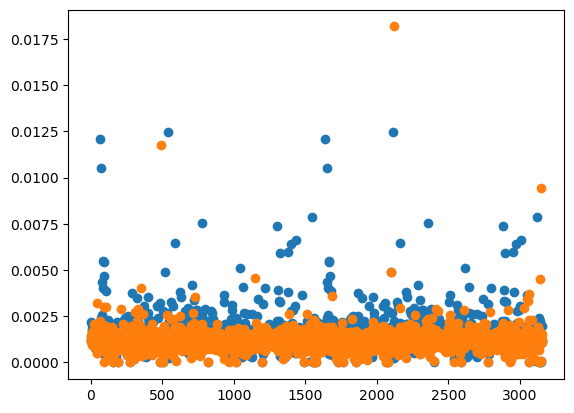

In [15]:
n_points = np.arange(len(all_probs_of_interest))
plt.scatter(n_points, all_probs_of_interest[:,0], label='P(talkr A word)')
plt.scatter(n_points, all_probs_of_interest[:,1], label='P(talkr B word)')

## Test on swc stim 

In [16]:
output_dict = {'results': None, 'confusions': None}
accuracies = []
pred_list = []
true_word_int = []

with torch.no_grad(): 
    for batch in tqdm(dataloader):
        # cue, fg, bg, label, confusion = batch
        cue, fg, label, confusion = batch
        # just running diotically on fg 
        # cue, _ = audio_transforms(cue.cuda(), None)
        # mixture, _ = diotic_transforms(fg.cuda().squeeze(), None)
        # cue = cue.cuda()
        # mixture = mixture.cuda()
        cue, fg = coch_gram(cue.cuda(), fg.cuda())
        # cue_mask_ixs = torch.arange(cue.shape[0])
        logits = model(cue, fg, None)

        preds = logits.softmax(dim=-1).argmax(dim=-1).cpu().detach().numpy().astype('int')
        true_word = label.numpy().astype('int')
        accuracy = (preds == true_word).astype('int')
        accuracies.append(accuracy)
        pred_list.append(preds)
        true_word_int.append(true_word)
accuracies = np.concatenate(accuracies)
pred_list = np.concatenate(pred_list)
true_word_int = np.concatenate(true_word_int)

output_dict['results'] = accuracies
output_dict['preds'] = pred_list
output_dict['true_word_int'] = true_word_int


 98%|█████████▊| 65/66 [08:04<00:07,  7.11s/it]/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torch/overrides.py:110: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  torch.has_cuda,
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torch/overrides.py:111: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  torch.has_cudnn,
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torch/overrides.py:117: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  torch.has_mps,
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torch/overrides.py:118: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  torch.has_mkldnn,
100%|██████████| 66/66 [08:24<00:00,  7.64s/it]


In [17]:
print(f"Accuracy without attention : {np.mean(accuracies):.2f}, ({stats.sem(accuracies):.2f})")

Accuracy without attention : 0.85, (0.01)


In [18]:
print(f"Accuracy: {accuracies.mean():.2f}, ({stats.sem(accuracies):.2f})")

Accuracy: 0.85, (0.01)


In [19]:
print(f"Accuracy: {accuracies.mean():.2f}, ({stats.sem(accuracies):.2f})")

Accuracy: 0.85, (0.01)


In [20]:
logits.softmax(-1).argmax(-1)

tensor([  1, 636, 614, 786,  97, 275, 483, 107, 507, 279, 751, 727, 778, 776,
        514, 326, 412, 260, 134, 201, 480, 305, 115, 161, 441,   3, 337, 545,
        377, 694, 248, 167,  80,  18, 305, 319], device='cuda:0')

In [21]:
label

tensor([  1, 636, 614, 786,  97, 275, 483, 107, 507, 279, 751, 727, 703, 776,
        514, 242, 412, 260, 134, 201, 480, 305, 115, 161, 441,   3, 337, 545,
        377, 694, 248, 329,  80,  18, 386, 319])

In [22]:

print(f"Accuracy: {accuracies.mean():.2f}, ({stats.sem(accuracies):.2f})")

Accuracy: 0.85, (0.01)


### Try with spatialization 

In [23]:
output_dict = {'results': None, 'confusions': None}
accuracies = []
confusions = []
pred_list = []
true_word_int = []

with torch.no_grad(): 
    for batch in tqdm(dataloader):
        cue, fg, bg, label, confusion = batch

        cue = tar_brir(cue.cuda())
        foreground = tar_brir(fg.cuda())
        background_l = dist_brir_l(bg.cuda())
        background_r = dist_brir_r(bg.cuda())
        # cue = np.array(spatialize(cue.cuda(), cue_brir)[:, :, 12500:137500])
        # foreground = np.array(spatialize(fg.cuda(), tar_brir)[:, :, 12500:137500])
        # background = np.array(spatialize(bg.cuda(), dist_brir)[:, :, 12500:137500])
        cue, _ = audio_transforms(cue, None)
        mixed_bg, _ = audio_transforms_0_db(background_l, background_r)
        mixture, _ = audio_transforms_test_db(foreground, mixed_bg)
        # cue = cue.cuda()
        # mixture = mixture.cuda()
        cue, mixture = coch_gram(cue, mixture)
        logits = model(cue, mixture, None)

        preds = logits.softmax(dim=-1).argmax(dim=-1).cpu().detach().numpy().astype('int')
        true_word = label.numpy().astype('int')
        con_word = confusion.numpy().astype('int')
        accuracy = (preds == true_word).astype('int')
        cons = (preds == con_word).astype('int')
        accuracies.append(accuracy)
        confusions.append(cons)
        pred_list.append(preds)
        true_word_int.append(true_word)
accuracies = np.concatenate(accuracies)
confusions = np.concatenate(confusions)
preds = np.concatenate(pred_list)
true_word_int = np.concatenate(true_word_int)

output_dict['results'] = accuracies
output_dict['confusions'] = confusions
output_dict['preds'] = preds
output_dict['true_word_int'] = true_word_int


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/66 [00:05<?, ?it/s]


ValueError: not enough values to unpack (expected 5, got 4)

In [ ]:
## Flanked at +/-0 degrees presented at 3dB SNR
print(f"Accuracy: {accuracies.mean()}")
print(f"Confusions: {confusions.mean()}")

Accuracy: 0.49366286438529783
Confusions: 0.09949302915082382


In [ ]:
## Flanked at +/-90 degrees presented at 3dB SNR
print(f"Accuracy: {accuracies.mean()}")
print(f"Confusions: {confusions.mean()}")

Accuracy: 0.5199619771863118
Confusions: 0.08428390367553866


In [ ]:
## Flanked at +90 degrees presented at 0dB SNR
# print(f"Accuracy: {accuracies.mean()}")
# print(f"Confusions: {confusions.mean()}")

Accuracy: 0.6552598225602028
Confusions: 0.0031685678073510772


In [ ]:
# ## Flanked at +/-90 degrees presented at 0dB SNR
# print(f"Accuracy: {accuracies.mean()}")
# print(f"Confusions: {confusions.mean()}")

Accuracy: 0.42870722433460073
Confusions: 0.13561470215462612


In [ ]:
# ## Flanked at +/-30 degrees 
# print(f"Accuracy: {accuracies.mean()}")
# print(f"Confusions: {confusions.mean()}")

Accuracy: 0.4134980988593156
Confusions: 0.15304182509505704


In [ ]:
mixed_bg, _ = audio_transforms(background_l, background_r)
mixed_scene, _ = audio_transforms(foreground, mixed_bg)

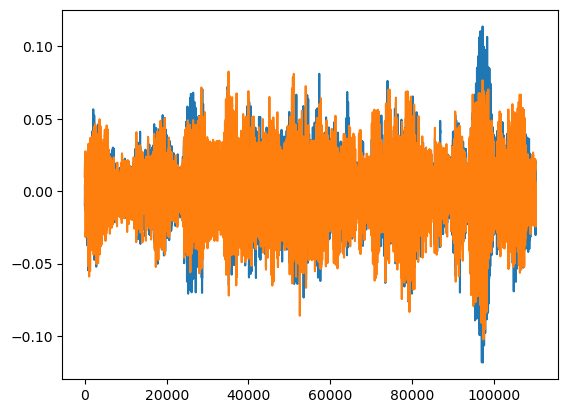

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(mixed_scene.cpu().numpy().squeeze().T)

In [ ]:
import IPython.display as ipd

print("Just background")
ipd.display(ipd.Audio(mixed_bg.squeeze().cpu(), rate=model_in_sr))
print("Scene")

ipd.display(ipd.Audio(mixed_scene.squeeze().cpu(), rate=model_in_sr))

Just background


Scene
